# 3. Method 2: De Novo Sequencing with Transformers (Casanovo)

## Goals:

In this notebook, we'll be exploring the following three core concepts:

1. [Why de novo sequencing is needed, and what happens when there's no database to search against.](#31-what-if-theres-no-database)

2. [How positional encoding translates raw m/z values into rich, multi-scale vector representations.](#34-positional-encoding)

3. [How Casanovo's Transformer architecture (encoder, decoder, and beam search) predicts full peptide sequences directly from spectra.](#311-casanovos-transformer-architecture)

In [ ]:
# @title Run this cell to import all necessary packages

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import torch

from util import *
from depthcharge.encoders import sinusoidal

## 3.1 What if there's no database?

In the previous notebook, we used spectrum binning + feature hashing to cluster spectra and match them against a database. But what happens when:
- You're studying a new organism with no reference proteome?
- You want to discover novel peptides or variants not in any database?
- You need to identify antibodies or other highly variable sequences?

How do you identify peptides then?

Remember that when we use databases, someone has already done the hard work of sequencing the proteins and translating them into peptide sequences. We just match spectra to these known sequences.

De novo sequencing aims to solve all of these problems by predicting the peptide sequence directly from the spectrum, no database required.

## 3.2 Translation Analogy

I'll connect it back to Mass Spectrometry in just a second, but consider this problem. The challenge of making machine learning models for the purpose of translation is quite an old one (in fact Google Translate is an example).

Suppose we are trying to:

1. Take in a paragraph of English text
2. Spit out a corresponding paragraph of French text

That's it! Recent advancements in the field of mass spectrometry have found a way to implement this analogy between mass spectra and their corresponding peptide sequences too. The translation here would be:

1. Take in a spectrum
2. Spit out the corresponding peptides for this spectrum

This is a form of *De novo sequencing*, since we don't have a database to compare anything to. We're simply "predicting" identifications without any outside knowledge.

I will mention though, that in the last notebook we represented *entire spectra* as single fixed-size vectors. Here, the translation model reads a spectrum *peak by peak*. Each individual peak gets its own numerical representation, where we can treat one peak as a single word to translate. 

So from here on, our focus is on how to represent a *single peak* in a way a model can learn from.

### Transformer

Few papers have been as influential as [Attention Is All You Need](https://arxiv.org/abs/1706.03762). It introduced the **Transformer**, a model architecture built specifically for *translation* tasks, like converting an English sentence into French.

The key insight was **attention**: when predicting the next output word, the model doesn't treat all input words equally. It learns to *attend*, to focus more on the words that are most relevant to the current prediction.

![Self-Attention](https://figures.academia-assets.com/101672149/figure_012.jpg)

In the image above, each word attends to the words before it with different strengths (darker = more attention). So "is" attends to "FBI" because "is" refers to the FBI performing some action.

This matters because language isn't a bag of independent words. Words depend on each other, and those dependencies carry meaning. Attention lets the model capture that structure.

The reason this is relevant here is that Casanovo frames de novo sequencing as *translation*. Instead of English -> French, it's spectrum -> peptide. And instead of words attending to words, **peaks attend to other peaks**. A fragment ion at m/z = 600 might carry more meaning in the context of a nearby ion at m/z = 601 (a ~1 Th gap). Attention lets the model discover those relationships automatically from data.

---


## 3.3 The Representation Problem

Recall that machines don't see mass spectra, they see numbers. In Notebook 2, we turned each spectrum into a list of "scrambled" numbers through binning and hashing. Same idea here, but now we need the model to understand *where* each individual peak lives.

If we want to train a translation model, how does it know if a word is the 1st word or the 600th? From a purely computational view, if we had a bunch of words that we fed (as numbers) into a machine learning model and expected output, the model has no idea which words are where, we need to imbue that knowledge into those numbers somehow.

Now map this to spectra: how does our model know whether a peak is at m/z = 100 or m/z = 600?

"Imbuing" this knowledge is actually not as trivial as it sounds.

Our goal is to do this abstract "translation" from peaks -> peptides right now. In order to do that, we need to represent a) intensity and b) m/z values for our model to read.

For now, we'll set our sights on m/z though.

---

### Attempt 1: Just use the number

M/Z values are already numbers right? Why are we trying to overcomplicate this? Just give a model the peak at $m/z = 600$ for example.

The drawback to this is that we lose the idea that we can "attend" to different peaks. See, just like we measured similarity in the last notebook with cosine similarity, here we use just the dot product. And dotting 2 random peaks at $600 \cdot 100$ for example, won't result in a useful answer. 

*In fact, this is a property of most machine learning models; they can't do subtraction out of the box.* 

They "learn" via matrix multiplication and division. So we'd lose the idea that 600 is ~500 m/z away from 100, because that's simply not a property of our model.

---

### Attempt 2: Binary

Okay, so raw numbers won't work. What about binary? The peak at m/z = 8 would be represented as `1000`:

| m/z | Binary |
|-----|--------|
| 1 | `0001` |
| 2 | `0010` |
| 4 | `0100` |
| 8 | `1000` |

This means that the last bit flips every 1 m/z, the next bit flips every 2 m/z, the next every 4 m/z, and so on. This allows us to try and capture the idea of "close" and "far" peaks. For example, m/z = 6 (`0110`) and m/z = 7 (`0111`) are neighbors.

This is more compact! We only need about 11 bits to represent m/z up to 2000. But binary has its own problem: m/z = 7 (`0111`) and m/z = 8 (`1000`) are *neighbors*, yet their binary representations differ in **every single bit**. The model has no sense of "closeness" because 7 and 8 look as different as 7 and 1000. Again, it cannot add or subtract as we can.

---

### What if we could smooth binary out?

Notice that binary digits flip between 0 and 1 at different rates: the rightmost bit flips every step, the next bit every 2 steps, the next every 4, and so on. What if instead of hard 0/1 flips, we used smooth, continuous oscillations at these different frequencies?

Most machine learning models rely on continuity between positions in order to "train their weights" with calculus. If we can create a representation where nearby m/z values have similar representations, the model can learn to attend to those relationships. 

That's exactly what **sinusoidal positional encoding** does.

---

## 3.4 Sinusoidal Positional Encoding Formula

It doesn't take too much of a leap to think of plain old sine and cosine functions to smooth out this binary representation. In fact, instead of just 11 dimensions (number of bits needed to represent the highest m/z values), we can use as many waves as we want, each with a different frequency. 
- 11 dimensions would mean that we jump a lot across frequencies. That is, if the first bit flips every 1 m/z, the next every 2 m/z, the next every 4 m/z, etc., then the 11th bit would flip every 1024 m/z. That's a huge jump in sensitivity from one bit to the next. What if we want to represent 0.1 m/z differences? Or 2.30 m/z? This is why we use many more dimensions to get a smoother representation across the m/z range.

**The core idea will hold though: we are still encoding m/z values as numbers, some of which flip really fast (sensitive to small m/z changes) and some of which flip really slow (sensitive to large m/z changes).**


 For each m/z value, we'll compute one number per wave and collect them into a vector. That vector *is* the sinusoidal positional encoding of that m/z value.

<details><summary><strong>Sine wave terminology refresher (click to expand)</strong></summary>

$$
y = A\sin\big(B(x - h)\big) + k
$$

$$
\begin{aligned}
\text{Amplitude} &= |A|, \\
\text{Midline} &= k, \\
\text{Period} &= \frac{2\pi}{|B|}, \\
\text{Phase shift} &= 
\begin{cases}
\text{right } h & \text{if } h < 0,\\
\text{left } h & \text{if } h > 0.
\end{cases}
\end{aligned}
$$

The **period** is what we care about most here. It controls how quickly the wave oscillates, just like in binary, and with our "rulers," which we'll get to in a second.

</details>

---

### The idea in one line

For a given m/z value and a wavelength $\lambda_i$, compute:

$$
\sin\!\left(\frac{m/z}{\lambda_i}\right)
$$

That's it. Plug in an m/z, get a number between −1 and 1. Different $\lambda_i$ values give different sensitivities to different m/z ranges. 

If we think of each $\lambda_i$ as a different "ruler" for measuring changes in m/z just like our binary example, then:
- A small $\lambda_i$ makes a fast-oscillating wave (fine ruler), a large $\lambda_i$ makes a slow one (coarse ruler).

Do this for 256 different wavelengths, and you have a 256-dimensional vector encoding one peak.

---

### Choosing the wavelengths $\lambda_i$


The wavelengths $\lambda_i$ are spaced *exponentially* from $\lambda_{\text{min}} = 0.001$ to $\lambda_{\text{max}} = 10{,}000$:

$$
\lambda_i = \frac{\lambda_{\text{min}}}{2\pi} \left( \frac{\lambda_{\text{max}}}{\lambda_{\text{min}}} \right)^{i / (d - 1)}, \quad i = 0, 1, \dots, d-1
$$

Imagine a list of 256 wavelengths increasing exponentially:
$$\lambda = [0.001, \;\dots,\; 10{,}000]$$

Each wavelength is a different "ruler": short wavelengths detect tiny m/z differences (isotopes, noise), long wavelengths distinguish broad spectrum regions. Together they let the model read position at many scales simultaneously.

- $d$ = total encoding dimensions. Casanovo uses $d = 512$.

---

### Full Sinusoidal Positional Encoding Formula

Casanovo uses **both** sine and cosine, which doubles the dimensions to 512. (Why both? We cover this later.)

The total dimensions are split into two halves:

$$d_{\text{sin}} = \frac{d}{2} \tag{1}$$

$$d_{\text{cos}} = d - d_{\text{sin}} \tag{2}$$

And the encoded features for some $\text{m/z}$ peak called $m_j$ are:

$$f_i(m_j) = \begin{cases} \sin\left( \frac{m_j}{\lambda_i} \right), & \text{for } i \leq d/2 \\[6pt] \cos\left( \frac{m_j}{\lambda_i} \right), & \text{for } i > d/2 \end{cases} \tag{3}$$

where $\lambda_{\text{max}} = 10{,}000$ and $\lambda_{\text{min}} = 0.001$.


- **For our examples, we'll focus only on the sine half** ($i \leq d/2$, i.e., the first 256 dimensions).

---

<details><summary><strong>Numerical example</strong></summary>

Consider the sine wave at $i = 1$ (second wavelength, out of 6 total for illustration):

$$\sin\!\left(\frac{x}{(0.001/2\pi)(10{,}000/0.001)^{1/2}}\right)$$

Its period:
$$
\text{Period} = \frac{2\pi}{B}, \quad B = \frac{1}{\left(\frac{0.001}{2\pi}\right)\left(\frac{10000}{0.001}\right)^{1/2}} = 2\pi \cdot \frac{0.001}{2\pi} \cdot 3162.277 \approx 3.162
$$

So this wave completes one full cycle every **~3.16 m/z units**.

![A single period plotted for this sine wave](desmos_1.png)

</details>

## 3.5 Low-Dimensional Numerical Example

To build intuition, we'll use $d = 6$ dimensions (instead of Casanovo's 256 for sine) and trace exactly what the formula produces.

Recall the wavelength formula from [3.4](#34-sinusoidal-positional-encoding-formula):

$$\lambda_i = \frac{\lambda_{\min}}{2\pi} \left(\frac{\lambda_{\max}}{\lambda_{\min}}\right)^{i/(d-1)}, \quad i = 0, 1, \dots, 5$$

with $\lambda_{\min} = 0.001$, $\lambda_{\max} = 10{,}000$. Each $\sin(m/z \,/\, \lambda_i)$ has **period** $2\pi \times \lambda_i$. This implies the $2\pi$ in the wavelength formula isn't magic, it's just pre-compensating for this factor so that the periods land on the clean exponential grid from $0.001$ to $10{,}000$ rather than on $0.001/2\pi$ to $10{,}000/2\pi$.


<details><summary><strong>How do we compute the period of this wave?</strong></summary>

Recall from above that for a general sine wave:

$$\sin(Bx) \quad \text{has period} \quad \frac{2\pi}{B}$$

In our case the argument is $\dfrac{m/z}{\lambda_i}$, so $B = \dfrac{1}{\lambda_i}$, giving:

$$\text{period} = \frac{2\pi}{1/\lambda_i} = 2\pi \times \lambda_i$$


---
</details>

### Computing the six wavelengths:

$$
\begin{aligned}
\lambda_0 &= \frac{0.001}{2\pi} \times (10^7)^{0/5} = \frac{0.001}{2\pi} \times 1 &&= 0.00016 \\
\lambda_1 &= \frac{0.001}{2\pi} \times (10^7)^{1/5} = \frac{0.001}{2\pi} \times 25.11886 &&= 0.00400 \\
\lambda_2 &= \frac{0.001}{2\pi} \times (10^7)^{2/5} = \frac{0.001}{2\pi} \times 630.95734 &&= 0.10042 \\
\lambda_3 &= \frac{0.001}{2\pi} \times (10^7)^{3/5} = \frac{0.001}{2\pi} \times 15848.93192 &&= 2.52244 \\
\lambda_4 &= \frac{0.001}{2\pi} \times (10^7)^{4/5} = \frac{0.001}{2\pi} \times 398107.17055 &&= 63.36072 \\
\lambda_5 &= \frac{0.001}{2\pi} \times (10^7)^{5/5} = \frac{0.001}{2\pi} \times 10000000 &&= 1591.54943
\end{aligned}
$$

> Note: $\lambda_{\max}/\lambda_{\min} = 10000/0.001 = 10^7$, so each step multiplies by $(10^7)^{1/5} \approx 25.12$.

**The resulting periods** $2\pi \times \lambda_i$ land exactly on the exponential grid too ($\times \sim 25$ each time):

| $i$ | $\lambda_i$ | Period $= 2\pi \times \lambda_i$ | Sensitivity |
|-----|-------------|----------------------------------|-------------|
| 0 | 0.00016 | 0.001 m/z | Below instrument noise floor. No real signal at this resolution |
| 1 | 0.00400 | 0.025 m/z | Isotope spacing for highly charged ions (e.g. z=40 → 1/40 Da apart) |
| 2 | 0.10042 | 0.631 m/z | Isotope envelope width for singly/doubly charged ions (~0.5–1 Da) |
| 3 | 2.52244 | 15.849 m/z | Residue-level differences (amino acid masses range ~57–186 Da) |
| 4 | 63.36072 | 398.107 m/z | Peptide precursor range (a 3–4 residue peptide spans ~300–500 Da) |
| 5 | 1591.54943 | 10,000 m/z | Full instrument range (distinguishes which broad spectral region) |

**Sinusoidal Positional Encoding for a peak at $m/z = 600$:**

$$\mathbf{f}(600) = \left[\sin\!\left(\frac{600}{\lambda_i}\right)\right]_{i=0}^{5} = [\approx 0,\; 0.42445,\; -0.39186,\; -0.78066,\; -0.04480,\; 0.36812]$$

> $i=0$ cycles so rapidly at this scale that its value is effectively arbitrary noise, as you'll see in the video and in the table below


Note that sinusoidal positional encoding isn't just a math formula you plug numbers into or memorize. It has deep geometric intuition which we've somewhat introduced, and the best way to understand it is to see it in action whilst encoding a peak at $m/z = 600$:


<video controls style = "width: 75%;">
  <source src="SinusoidalPE.mp4" type="video/mp4">
</video>


**Tracing $m/z = 600 \to 601$:**


$$\mathbf{f}(601) = [\approx 0,\; 0.99838,\; -0.13037,\; -0.47880,\; -0.06056,\; 0.36871]$$


| $i$ | Period | Cycles in 1 m/z | $\sin$ at 600 | $\sin$ at 601 | $\Delta$ |
|-----|--------|-----------------|---------------|---------------|----------|
| 0 | 0.001 | 1000.00 | ≈ 0 | ≈ 0 | 0: Completes 1000 full cycles: value is arbitrary, not meaningful |
| 1 | 0.025 | 39.81 | 0.42445 | 0.99838 | **+0.574**: wraps ~40×: better but not uniquely locating |
| 2 | 0.631 | 1.58 | −0.39186 | −0.13037 | **+0.261**: just over one full cycle, still changes a lot |
| 3 | 15.849 | 0.063 | −0.78066 | −0.47880 | **+0.302:** 6% of a cycle; still meaningfully shifts the vector |
| 4 | 398.107 | 0.003 | −0.04480 | −0.06056 | **−0.016:** barely 0.3% of a cycle; nearly identical |
| 5 | 10,000 | 0.0001 | 0.36812 | 0.36871 | **+0.001**: 600 and 601 are indistinguishable here, by design |

</br>

**Recall that the model has no explicit subtraction operator to compare two peaks**. 

The model compares peaks via dot products between their encoding vectors, not by explicitly computing differences. Recall from above that it cannot do subtraction out of the box. This implies that it can't compute $\mathbf{f}(601) - \mathbf{f}(600)$ and read off the difference. Rather, the coarse waves ensure that nearby peaks have high dot product similarity; the fine waves are what break ties between peaks that are close but not identical.

### Summary

The broad idea is that waves ($i=4,5$) are what **locate** a peak in the spectrum. They change slowly enough to be monotonically informative across large m/z ranges. Fine waves ($i=1,2$) change too rapidly to locate, but are sensitive enough to distinguish nearby peaks once the coarse waves have narrowed the region. 


So when we relate this back to the question of "*how does a model know if a peak is at m/z = 100 or 600?*", the answer is that the coarse waves will be very different between those two m/z values, giving the model a strong signal about their relative positions. The fine waves will then provide additional detail about the local structure of the spectrum around those positions.




> **Desmos link for all graphs:** https://www.desmos.com/calculator/he8fjmng6v 
 - (note that we only made the coarser waves more visible by default, but you can toggle the fine ones on/off)

---

## 3.6 Why Both Sine AND Cosine?

Throughout this explanation, you may have seen various references to "we'll just focus on the sine part of the equation for now" (see full positional encoding equation image for reference). The reason we use both sine and cosine is elegant: it allows the model to compute relative positions using simple linear algebra.

### "How does a model know if a peak is at m/z = 100 or 600?"

Consider what happens in the imaginary case wherein we get the exact same encoding for both $m/z = 100$ and $m/z = 600$ for the sine waves.

That is, $\sin(100/\lambda) = \sin(600/\lambda)$. This is not only possible, but it will happen. The idea is that sine waves are not one-to-one functions; they repeat in every single period. So it's inevitable that some pairs of m/z values will produce identical sine encodings, making them indistinguishable if we only had sine.

For a trivial example:

$$\sin(0) = \sin(2\pi) = \sin(4\pi) = 0$$

There are two complementary fixes to this problem.

Within a single period, adding cosine resolves all ambiguity: $(\sin\theta, \cos\theta)$ uniquely identifies any angle in $[0, 2\pi)$. I encourage you to try to find two different angles that have the same sine and cosine values. You won't be able to, *because the pair together is a unique coordinate on the unit circle*.

*Across periods, cosine alone is not enough*. Any two m/z values differing by exactly one full period will still collide:
$$\mathbf{f}(0) = [\sin(0),\ \cos(0)] = [0,\ 1]$$
$$\mathbf{f}(2\pi) = [\sin(2\pi),\ \cos(2\pi)] = [0,\ 1]$$

So in 2 different circles, we have the same point. The model can't tell if it's looking at m/z = 0 or m/z = 2π just from the sine and cosine of that single wavelength.

This is where many wavelengths come in. 256 of each sine and cosine wave, to be exact. Two m/z values that collide at one wavelength would need to collide at every wavelength simultaneously to be truly indistinguishable. 

Since the wavelengths are spaced exponentially and are irrational multiples of each other, this never happens over any realistic m/z range.

Uniqueness in the full encoding comes from both fixes together: cosine handles ambiguity within a period, and many incommensurate wavelengths handle ambiguity across periods.


**Full proof:** [Linear Relationships in Positional Encoding](https://blog.timodenk.com/linear-relationships-in-the-transformers-positional-encoding/)

</details>

# Part II: Implementing Positional Encoding

## 3.7 Code Implementation

The intuition + math was the hard part. Let's implement the positional encoding (in ~10 lines of code) and visualize how it works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from util import *
from depthcharge.encoders import sinusoidal
import torch

ModuleNotFoundError: No module named 'spectrum_utils'

Recall that both sine and cosine encodings use the same list of wavelengths. 

A single set of 256 wavelengths is applied to compute both the sine and cosine components, giving us 512 total dimensions (256 sine + 256 cosine).

In [2]:
def make_wavelength_list(dimensions: int, lambda_min: float = 0.001, lambda_max: float = 10000) -> np.ndarray:
    """
    Generate wavelengths following the Casanovo formula:
    ꟛ_i = (ꟛ_min / 2π) * (ꟛ_max / ꟛ_min)^(i / (d_sin - 1))
    
    Args:
        d_model: Total dimensions (split evenly between sin/cos)
        lambda_min: Minimum wavelength (default: 0.001, as in Casanovo)
        lambda_max: Maximum wavelength (default: 10000, as in Casanovo)
    Returns: 
        Array of d_model // 2 wavelengths
    """
    d_sin = dimensions // 2
    wavelengths = np.zeros(d_sin)
    for i in range(d_sin):
        wavelengths[i] = (lambda_min / (2 * np.pi)) * (lambda_max / lambda_min) ** (i / (d_sin - 1))
    return wavelengths

# Let's see what wavelengths look like for 512 dimensions
wavelengths = make_wavelength_list(512)
print(f"Number of wavelengths: {len(wavelengths)}")
print(f"Smallest wavelength: {wavelengths[0]:.6f}")
print(f"Largest wavelength: {wavelengths[-1]:.6f}")
print(f"\nFirst 10 wavelengths: {wavelengths[:10]}")

Number of wavelengths: 256
Smallest wavelength: 0.000159
Largest wavelength: 1591.549431

First 10 wavelengths: [0.00015915 0.00016954 0.0001806  0.00019239 0.00020494 0.00021831
 0.00023256 0.00024773 0.00026389 0.00028111]


In [3]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, dimensions=512, lambda_min=0.001, lambda_max=10000):
    """
    Encode a single m/z value into a d_model-dimensional vector.
    
    First d_model/2 dimensions: sine encoding
    Last d_model/2 dimensions: cosine encoding
        
    Args:
        m_z: The m/z value to encode
        d_model: Total dimensionality of the encoding
        lambda_min, lambda_max: Wavelength range
    
    Returns:
        numpy array of shape (d_model,)
    """
    encoding = np.zeros(dimensions)
    d_sin = dimensions // 2
    wavelengths = make_wavelength_list(dimensions)
    for d in range(d_sin):
        wavelength = wavelengths[d]
        encoding[d] = np.sin(m_z / wavelength)           # First half: sine
        encoding[d + d_sin] = np.cos(m_z / wavelength)   # Second half: cosine
    
    return encoding

Let's go through a small, but very revealing example.

Similarity (dot product) comparisons:
  1000 vs 1000.1 (similar m/z):   151.82
  1000 vs 126.127 (different m/z): -13.13

→ Similar m/z values have higher dot products (more similar encodings)


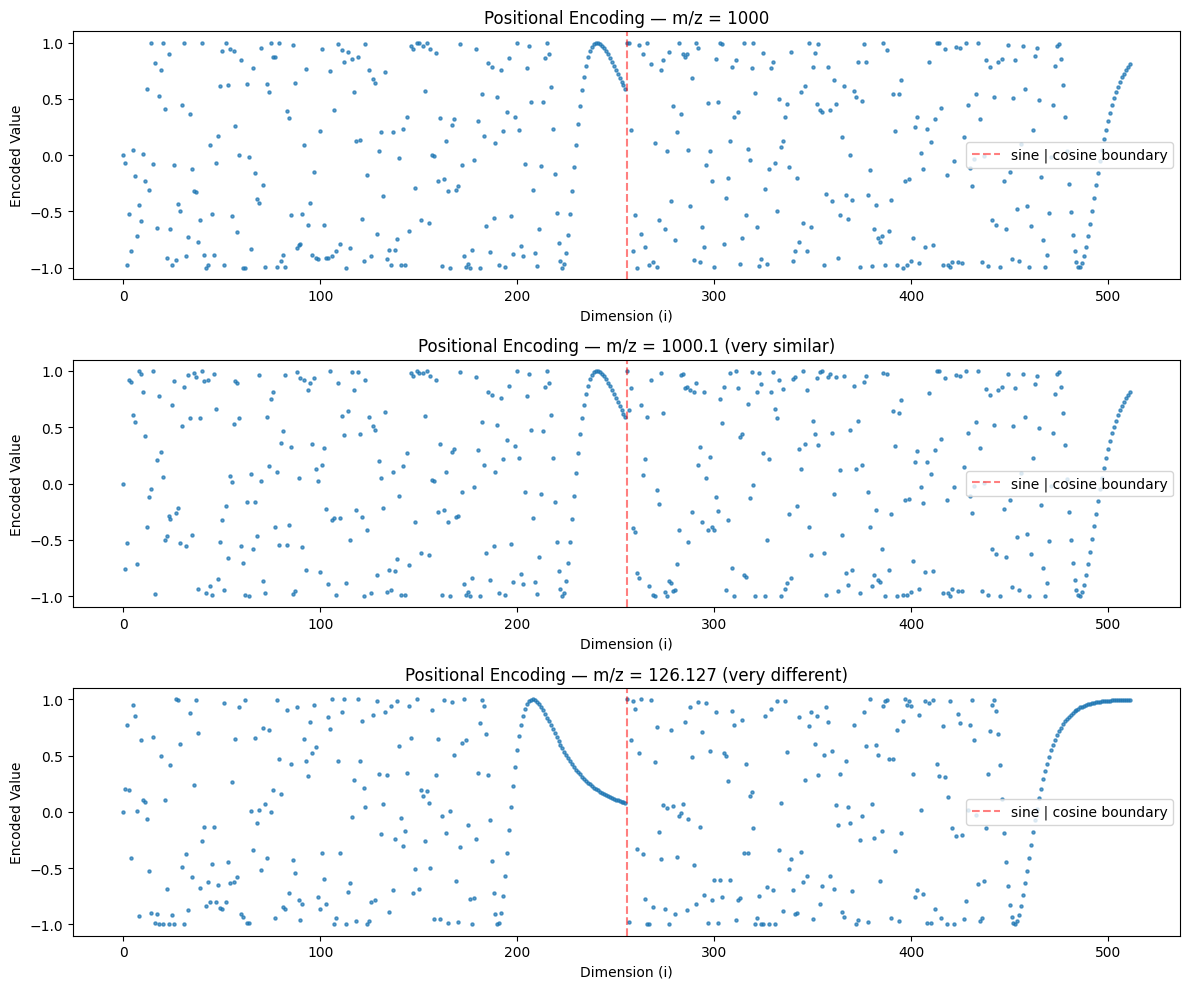

In [4]:
# Encode three different m/z values
encode_100 = positional_encoding(100)
encode_600 = positional_encoding(600)
encode_601 = positional_encoding(601)  # Very close to 600

# Check similarity using dot product
print("Similarity (dot product) comparisons:")
print(f"  600 vs 601 (similar m/z):   {np.dot(encode_600, encode_601):.2f}")
print(f"  600 vs 100 (different m/z): {np.dot(encode_600, encode_100):.2f}")
print("\n→ Similar m/z values have higher dot products (more similar encodings)")

# Visualize the encodings
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, (enc, title) in zip(axes, [
    (encode_600, "Positional Encoding — m/z = 600"),
    (encode_601, "Positional Encoding — m/z = 601 (very similar)"),
    (encode_100, "Positional Encoding — m/z = 100 (very different)")
]):
    ax.scatter(range(len(enc)), enc, s=5, alpha=0.7)
    ax.axvline(x=256, color='red', linestyle='--', alpha=0.5, label='sine | cosine boundary')
    ax.set_title(title)
    ax.set_xlabel("Dimension (i)")
    ax.set_ylabel("Encoded Value")
    ax.legend()

plt.tight_layout()
plt.show()

### 3.10.1 Interpreting the Encoding Patterns

Looking at the scatter plots above, we can see a clear pattern:

| Dimension Range | Wavelength | Information Captured |
|-----------------|------------|---------------------|
| 0–50 (sine), 256–306 (cosine) | Short | High-resolution, changes rapidly with small m/z shifts |
| 200–255 (sine), 456–511 (cosine) | Long | Low-resolution, stable across nearby m/z values |

**Some Corollaries:**
- The left side of each plot (fine wavelengths) looks like noise. Recall our red wave? It was oscillating so fast that small m/z changes cause large value changes. Same idea here. Regardless of how fast it is though, more dimensions gives the model a clearer picture of what's happening at each m/z value.
- The right side (coarse wavelengths) shows smooth patterns - these change only for large m/z differences

Let's zoom in to see this more clearly:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compare LOW-resolution dimensions (coarse wavelengths: 200-255)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(range(200, 256), encode_600[200:256], label='m/z = 600', alpha=0.7)
axes[0].scatter(range(200, 256), encode_601[200:256], label='m/z = 601', alpha=0.7)
axes[0].set_title("COARSE Wavelengths (dims 200-255)\nShould be similar for nearby m/z")
axes[0].set_xlabel("Dimension (i)")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].scatter(range(200, 256), encode_600[200:256], label='m/z = 600', alpha=0.7)
axes[1].scatter(range(200, 256), encode_100[200:256], label='m/z = 100', alpha=0.7)
axes[1].set_title("COARSE Wavelengths (dims 200-255)\nShould be different for distant m/z")
axes[1].set_xlabel("Dimension (i)")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantify with cosine similarity
sim_nearby = cosine_similarity([encode_600[200:256]], [encode_601[200:256]])[0][0]
sim_distant = cosine_similarity([encode_600[200:256]], [encode_100[200:256]])[0][0]
print(f"Cosine similarity in coarse dimensions:")
print(f"  600 vs 601: {sim_nearby:.4f} (identical!)")
print(f"  600 vs 100: {sim_distant:.4f} (very different)")

In [ ]:
# Compare HIGH-resolution dimensions (fine wavelengths: 0-56)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(range(0, 57), encode_600[0:57], label='m/z = 600', alpha=0.7)
axes[0].scatter(range(0, 57), encode_601[0:57], label='m/z = 601', alpha=0.7)
axes[0].set_title("Fine Wavelengths (dims 0-56)\nCan distinguish SMALL m/z differences")
axes[0].set_xlabel("Dimension (i)")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].scatter(range(0, 57), encode_600[0:57], label='m/z = 600', alpha=0.7)
axes[1].scatter(range(0, 57), encode_100[0:57], label='m/z = 100', alpha=0.7)
axes[1].set_title("Fine Wavelengths (dims 0-56)\nHighly variable for all m/z")
axes[1].set_xlabel("Dimension (i)")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantify with cosine similarity
sim_nearby_fine = cosine_similarity([encode_600[0:57]], [encode_601[0:57]])[0][0]
sim_distant_fine = cosine_similarity([encode_600[0:57]], [encode_100[0:57]])[0][0]
print(f"Cosine similarity in FINE dimensions (0-56):")
print(f"  600 vs 601: {sim_nearby_fine:.4f}")
print(f"  600 vs 100: {sim_distant_fine:.4f}")
print(f"\n→ Fine wavelengths detect the 1 Th difference that coarse wavelengths missed!")

### Visualzing the Encodings
Here we use scan 9970 from the same mzML file as earlier. We plot the encoded m/z (512 dimensions) and intensity (512 dimensions) on the y-axis for each of the top 200 most intense peaks in the spectrum. The color represents the encoded value (between -1 and 1). The smooth, continuous bands across peaks show that Casanovo encoding preserves similarity within the spectrum: peaks that are close in m/z remain close in the encoded space across many dimensions, especially at the min and max m/z and intensity wavelengths.

In [ ]:
ms2_scan8090 = get_MS2_object('04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML', 9970)
encoder = sinusoidal.PeakEncoder(
    d_model=512,
    min_mz_wavelength=0.001,
    max_mz_wavelength=10000,
    min_intensity_wavelength=0.000001,
    max_intensity_wavelength=10,
    learnable_wavelengths=False,
)

# Normalize intensities to be between 0 and 1
max_intensity = max(ms2_scan8090.intensity)
for i in range(len(ms2_scan8090.intensity)):
    ms2_scan8090.intensity[i] /= max_intensity

# Make tensor
mz = torch.tensor(ms2_scan8090.mz, dtype=torch.float32)
intensity = torch.tensor(ms2_scan8090.intensity, dtype=torch.float32)
peaks = torch.stack([mz, intensity], dim=1)
X = peaks.unsqueeze(0) # Inserts new dimension for n_spectra = 1

mz = X[0, :, 0]
inten = X[0, :, 1] 

# Sort by intensity, take the top 200 peaks
order = torch.argsort(inten, descending=True)
mz_sorted = mz[order]
inten_sorted = inten[order]
mz_sorted = mz_sorted[:200] # Take top 200 peaks
inten_sorted = inten_sorted[:200] # Take top 200 peaks

# Sort by m/z
order = torch.argsort(mz)
mz_sorted = mz[order]
inten_sorted = inten[order]

X_sorted = torch.stack([mz_sorted, inten_sorted], dim=1).unsqueeze(0)  # (1, n_peaks, 2)

# Encode using PeakEncoder
encoder.eval()
with torch.no_grad():
    mz_enc = encoder.mz_encoder(X_sorted[:, :, 0])     # (1, n_peaks, 512)
    int_enc = encoder.int_encoder(X_sorted[:, :, 1])   # (1, n_peaks, 512)

# Stack the two encodings (n peaks x 1024)
E = torch.cat([mz_enc, int_enc], dim=2)
E = E.squeeze(0).T.cpu().numpy()

mz_sorted_np = mz_sorted.cpu().numpy()

# Plot heatmap
plt.figure(figsize=(16, 8))
im = plt.imshow(
    E,
    aspect="auto",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    cmap="plasma"
)
plt.colorbar(im, label="Encoded value (-1 to 1)")
plt.xlabel("Peaks (sorted by m/z)")
plt.ylabel("Encoding dimension (0–511 m/z, 512–1023 intensity)")
plt.title("AVVQDPALKPLALVYGEATSR Spectrum (Scan 9970) Top 200 Peak Encodings (m/z and Intensity)")

# Label a few x ticks with actual m/z values
n_peaks = E.shape[1]
xticks = np.linspace(0, n_peaks - 1, 10, dtype=int)
plt.xticks(xticks, [f"{mz_sorted_np[i]:.1f}" for i in xticks], rotation=0)

plt.tight_layout()
plt.show()


---

# Part III: From Encoding to Prediction

## 3.11 Casanovo's Transformer Architecture

Now that we understand how peaks are encoded, let's see how Casanovo uses these encodings to predict peptide sequences.

<img src='Casanovo Transformer Architecture.webp' width=500 height=500>

The model has three inputs:
1. **Encoded spectrum** — our 512-dimensional vectors for each peak
2. **Encoded precursor** — mass and charge of the intact peptide (sets the mass budget)
3. **Previously predicted amino acids** — enables autoregressive generation

The encoded spectrum is made up of 2 parts: the encoded m/z values and the encoded intensities.
Each peak’s intensity is encoded via a learned linear layer. The encoding is meant to convery how strong that fragment signal is. Intensities are normalized and incorporated into the peak encodings.

---

## 3.12 The Translation Analogy

Casanovo implements a Transformer encoder–decoder architecture with linear and softmax output layers and beam search decoding to map peak encodings and precursor information to amino acid sequences. Conceptually, it works like a language translation model. For example, if the model were translating from English to Spanish, the process would look like this:

### 3.12.1 Transformer Encoder-Decoder

| English → Spanish | Spectrum → Peptide |
|------------------|-------------------|
| Read English sentence | Read in fragment peaks from a mass spectrum |
| Encoder produces a contextual representation of the whole English sentence that captures the relationships between each word | Encoder produces a contextual representation of the spectrum (peak encoding + relationships) |
| Decoder receives Start token and predicts the first Spanish word using the encoded English sentence and the language model | Decoder receives Start token and predicts the first amino acid using the precursor m/z and the encoded spectrum |
| Decoder predicts subsequent Spanish words conditioned on prior predictions and the encoded source sentence | Decoder predicts subsequent amino acids conditioned on prior predictions and the encoded spectrum |
| Prediction ends when the decoder outputs End token, signaling a complete Spanish sentence | Prediction ends when the decoder outputs End token, signaling a complete peptide sequence |

---

### 3.12.2 Linear + Softmax Output

After the decoder produces a representation for the next position, it passes each representation through 2 output layers.

| | English → Spanish | Spectrum → Peptide |
|------------------|-------------------|------------------|
| **Linear Layer** | Computes a score for every possible Spanish word in the vocabulary | Computes a score for each of the ~27 possible outputs (20 amino acids + modifications + stop token) |
| **Softmax** | Converts those scores into a probability distribution over Spanish words | Converts scores to probabilities |
| **Example Output** | `[hola: 0.01, biblioteca: 0.12, casa: 0.63, …]` → Predict “casa” | `[Gly: 0.02, Ala: 0.05, ..., Lys: 0.71, ...]` → Predict **Lysine (K)** |

---

### 3.12.3 Beam Search Decoding

> Beam Search is just a simple backtracking with a fancy name. 

Instead of greedily picking the most likely amino acid at each step, beam search keeps the **top-k** candidates:

<img src='Beam Search Ex.webp' alt="Beam search visualization" width=600 height=300>

**How it works:**
1. Start with k=5 partial sequences
2. Extend each by all possible amino acids
3. Keep only the top-k most probable extensions
4. Prune sequences that exceed precursor mass
5. When all sequences terminate, return the highest-probability one

**Example calculation:**
$$
\begin{aligned}
P(ABC) &= P(A) \times P(B|A) \times P(C|AB) \\
       &= 0.5 \times 0.4 \times 0.8 = 0.16 \\
P(AED) &= P(A) \times P(E|A) \times P(D|AE)  \\
       &= 0.5 \times 0.5 \times 0.8 = 0.20
\end{aligned}
$$

→ "AED" wins over "ABC" even though individual probabilities varied!

> Beam search finds the **globally best sequence**, not just locally optimal choices (greedy). This is crucial because amino acid probabilities depend heavily on context.

In the end, the language translation model selects the **best overall sentence**, not just the best individual words. Casanovo selects the **highest-scoring peptide** as the predicted sequence, not just the best individual amino acids.

---

## 3.13 Summary: Why This Works

Let's connect everything back to the original problem:

### The Problem
We need to predict a peptide sequence from MS/MS peaks without a reference database.

### The Solution
1. **Positional Encoding** transforms raw m/z values into rich 512-dimensional vectors that:
   - Capture both fine-scale (isotopes) and coarse-scale (peptide regions) information
   - Enable linear transformations for learning relative positions
   - Allow the model to understand "this peak is 128 Th away from that one"

2. **Transformer Architecture** processes these encodings through:
   - Attention mechanisms that learn peak-to-peak relationships
   - Autoregressive decoding that builds sequences one amino acid at a time

3. **Beam Search** finds the globally optimal sequence by exploring multiple hypotheses simultaneously.

### The Lego Analogy (Complete)

| Step | Lego | Casanovo |
|------|------|----------|
| Representation | Measure each piece precisely | Encode each peak with multi-scale wavelengths |
| Pattern Recognition | "2x4 bricks connect to plates here" | "b-ions follow this pattern" |
| Sequential Assembly | Build one piece at a time | Predict one amino acid at a time |
| Quality Control | Check if pieces fit | Verify mass within tolerance |
| Backtracking | Try different assembly orders | Beam search explores alternatives |

---

## 3.14 Further Reading

- **Casanovo Paper:** [Sequence-to-sequence translation from mass spectra to peptides with a transformer model](https://www.nature.com/articles/s41467-024-49731-x)
- **Positional Encoding Deep Dive:** [Linear Relationships in Transformer Positional Encoding](https://blog.timodenk.com/linear-relationships-in-the-transformers-positional-encoding/)
- **Original Transformer Architecture:** [Attention Is All You Need](https://arxiv.org/abs/1706.03762)